In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset

In [3]:
df=pd.read_csv('bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
#Perform basic data exploration on features such as age, job, and marital status.
print(df['age'].describe())
print(df['job'].value_counts())
print(df['marital'].value_counts())


count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64


In [17]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

# Age Distribution

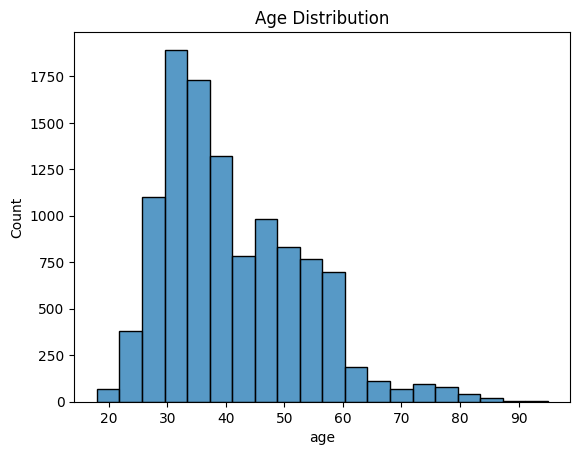

In [5]:
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

# Job vs Subscription status

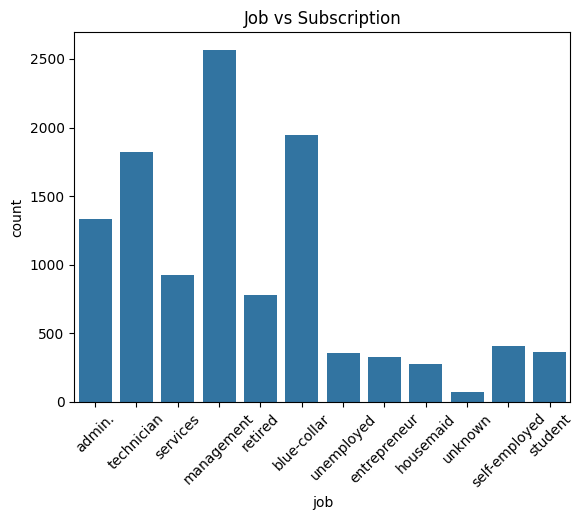

In [7]:
sns.countplot(x="job",  data=df)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()

# Marital status vs Subscription status

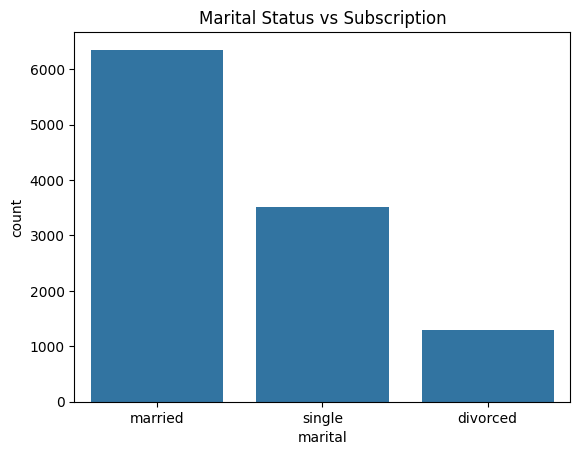

In [9]:
sns.countplot(x="marital", data=df)
plt.title("Marital Status vs Subscription")
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Encode categorical variables
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


In [12]:
# Scale numerical features
scaler = StandardScaler()
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
df[numerical_features] = scaler.fit_transform(df[numerical_features])


In [13]:
# Split the data into training and testing sets
X = df.drop('deposit', axis=1)
y = df['deposit']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Apply Logistic Regression and Random Forest Classifier to predict subscription status

In [ ]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

# Evaluate the Logistic Regression model
y_pred_logistic = logistic_model.predict(X_test)
acc=accuracy_score(y_test, y_pred_logistic)
clas=classification_report(y_test, y_pred_logistic)
conf=confusion_matrix(y_test, y_pred_logistic)
print("Logistic Regression Accuracy:", acc)
print("Logistic Regression Classification Report:\n", clas)
print("Logistic Regression Confusion Matrix:\n", conf)

Logistic Regression Accuracy: 0.7895208240035826
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.82      0.80      1166
           1       0.79      0.76      0.77      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233

Logistic Regression Confusion Matrix:
 [[955 211]
 [259 808]]


# Apply Random Forest Classifier to predict subscription status

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the Random Forest Classifier
y_pred_rf = rf_model.predict(X_test)    
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8351992834751455
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.86      0.83      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233

Random Forest Confusion Matrix:
 [[952 214]
 [154 913]]


In [19]:
#Analyze the results to identify which customer groups are more likely to accept the offer.
df.groupby("job")["deposit"].value_counts(normalize=True)

job  deposit
0    0          0.526987
     1          0.473013
1    0          0.635802
     1          0.364198
2    0          0.625000
     1          0.375000
3    0          0.602190
     1          0.397810
4    1          0.507015
     0          0.492985
5    1          0.663239
     0          0.336761
6    0          0.538272
     1          0.461728
7    0          0.600217
     1          0.399783
8    1          0.747222
     0          0.252778
9    0          0.539221
     1          0.460779
10   1          0.565826
     0          0.434174
11   0          0.514286
     1          0.485714
Name: proportion, dtype: float64

In [21]:
df.groupby("marital")["deposit"].value_counts(normalize=True)

marital  deposit
0        0          0.518948
         1          0.481052
1        0          0.566210
         1          0.433790
2        1          0.543491
         0          0.456509
Name: proportion, dtype: float64

In [22]:
df.groupby("age")["deposit"].value_counts(normalize=True)

age        deposit
-1.950161  1          0.875000
           0          0.125000
-1.866218  1          0.846154
           0          0.153846
-1.782275  1          0.750000
                        ...   
 4.009797  0          1.000000
 4.093740  1          1.000000
 4.261626  1          1.000000
 4.345569  1          1.000000
 4.513455  1          1.000000
Name: proportion, Length: 144, dtype: float64